In [28]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve().parent
SRC_PATH = PROJECT_ROOT / "src"
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"

if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("ARTIFACTS_DIR:", ARTIFACTS_DIR)

PROJECT_ROOT: /Users/amirhosseinlatifinavid/Desktop/Programming/Python /quant-ml-backtester
ARTIFACTS_DIR: /Users/amirhosseinlatifinavid/Desktop/Programming/Python /quant-ml-backtester/artifacts


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve().parent
SRC_PATH = PROJECT_ROOT / "src"

if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from quant_ml.config import INTERIM_DATA_DIR
from quant_ml.baseline import (
    compute_momentum_signal,
    equal_weight_portfolio,
    compute_strategy_returns,
)
from quant_ml.models import time_split, fit_predict_logistic
from quant_ml.signals import make_weekly_top_n_signals, equal_weight_from_signal
from quant_ml.models import time_split, fit_predict_logistic, fit_predict_rf

In [3]:
df = pd.read_parquet(INTERIM_DATA_DIR / "model_dataset_v1.parquet")
df["date"] = pd.to_datetime(df["date"])

In [4]:
split = time_split(df, train_end_date="2020-12-31")

train_df = split.train
test_df = split.test

In [5]:
baseline_df = test_df.copy()

baseline_df = compute_momentum_signal(baseline_df)
baseline_df = equal_weight_portfolio(baseline_df)

baseline_portfolio = compute_strategy_returns(baseline_df)

In [6]:
feature_cols = [
    "ret_1d", "ret_5d", "ret_20d", "ret_60d",
    "ma_ratio_20", "ma_ratio_50", "ma_ratio_100", "ma_cross_20_50",
    "vol_20d", "vol_60d",
    "volume_z_20", "volume_ratio_20",
    "fed_funds", "cpi", "unemployment", "10y_treasury", "2y_treasury", "term_spread",
]

target_col = "target_up_5d"

model, preds = fit_predict_logistic(
    train_df=train_df,
    test_df=test_df,
    feature_cols=feature_cols,
    target_col=target_col,
)

In [7]:
ml_df = make_weekly_top_n_signals(
    preds,
    score_col="proba_up",
    top_n=4,
)

ml_df = equal_weight_from_signal(ml_df)

ml_portfolio = compute_strategy_returns(ml_df)

In [8]:
common_index = baseline_portfolio.index.intersection(ml_portfolio.index)

baseline_aligned = baseline_portfolio.loc[common_index]
ml_aligned = ml_portfolio.loc[common_index]

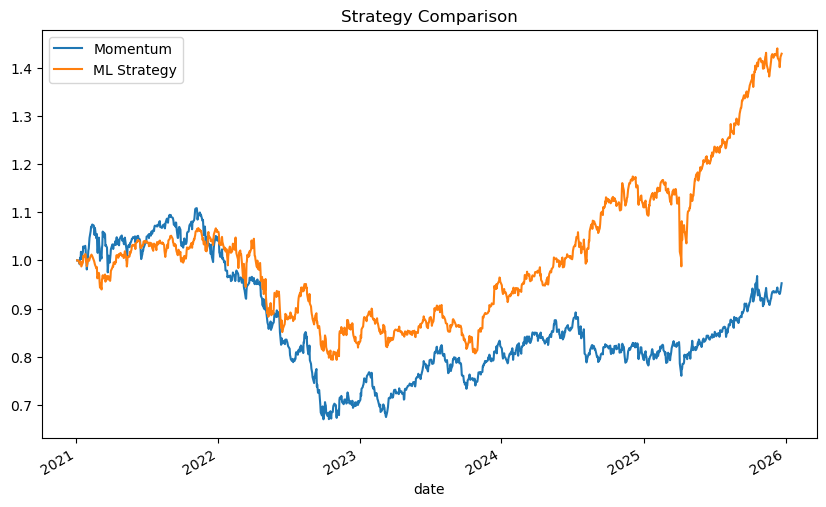

In [9]:
plt.figure(figsize=(10,6))

baseline_aligned["cum_return"].plot(label="Momentum")
ml_aligned["cum_return"].plot(label="ML Strategy")

plt.legend()
plt.title("Strategy Comparison")
plt.show()

In [10]:
def compute_metrics(portfolio):
    r = portfolio["net_return"].dropna()
    sharpe = (r.mean() / r.std()) * (252 ** 0.5)
    max_dd = (portfolio["cum_return"] / portfolio["cum_return"].cummax() - 1).min()
    return sharpe, max_dd

b_sharpe, b_dd = compute_metrics(baseline_aligned)
m_sharpe, m_dd = compute_metrics(ml_aligned)

print("Baseline Sharpe:", b_sharpe)
print("ML Sharpe:", m_sharpe)
print("Baseline DD:", b_dd)
print("ML DD:", m_dd)

Baseline Sharpe: 0.012260530337100105
ML Sharpe: 0.55552265939998
Baseline DD: -0.39515909104736646
ML DD: -0.2561053311781606


In [11]:
model, preds = fit_predict_logistic(
    train_df=train_df,
    test_df=test_df,
    feature_cols=feature_cols,
    target_col=target_col,
)

## Random Forest

In [12]:
model, preds = fit_predict_rf(
    train_df=train_df,
    test_df=test_df,
    feature_cols=feature_cols,
    target_col=target_col,
)

In [13]:
MODEL_NAME = "logistic"   
TOP_N = 3                 # try 2, 3, 4
TRAIN_END_DATE = "2020-12-31"

In [14]:
split = time_split(df, train_end_date=TRAIN_END_DATE)

train_df = split.train
test_df = split.test

In [15]:
feature_cols = [
    "ret_1d", "ret_5d", "ret_20d", "ret_60d",
    "ma_ratio_20", "ma_ratio_50", "ma_ratio_100", "ma_cross_20_50",
    "vol_20d", "vol_60d",
    "volume_z_20", "volume_ratio_20",
    "fed_funds", "cpi", "unemployment", "10y_treasury", "2y_treasury", "term_spread",
]

target_col = "target_up_5d"

if MODEL_NAME == "logistic":
    model, preds = fit_predict_logistic(
        train_df=train_df,
        test_df=test_df,
        feature_cols=feature_cols,
        target_col=target_col,
    )
elif MODEL_NAME == "rf":
    model, preds = fit_predict_rf(
        train_df=train_df,
        test_df=test_df,
        feature_cols=feature_cols,
        target_col=target_col,
    )
else:
    raise ValueError(f"Unsupported MODEL_NAME: {MODEL_NAME}")

preds.head()

,date,ticker,close,fwd_ret_5d,proba_up,pred_label
2166,2021-01-04,EEM,46.271252,0.037885,0.572734,1
2167,2021-01-05,EEM,47.383541,0.023474,0.542672,1
2168,2021-01-06,EEM,46.983116,0.034470,0.578313,1
2169,2021-01-07,EEM,47.428032,0.034334,0.590525,1
2170,2021-01-08,EEM,48.682697,-0.006580,0.523103,1


In [16]:
ml_df = make_weekly_top_n_signals(
    preds,
    score_col="proba_up",
    top_n=TOP_N,
)

ml_df = equal_weight_from_signal(ml_df)
ml_portfolio = compute_strategy_returns(ml_df)

ml_portfolio.head()

,gross_return,cost,net_return,cum_return
date,,,,
2021-01-04,0.0,0.000,0.000,1.000
2021-01-05,0.0,0.000,0.000,1.000
2021-01-06,0.0,0.000,0.000,1.000
2021-01-07,0.0,0.000,0.000,1.000
2021-01-08,0.0,0.001,-0.001,0.999


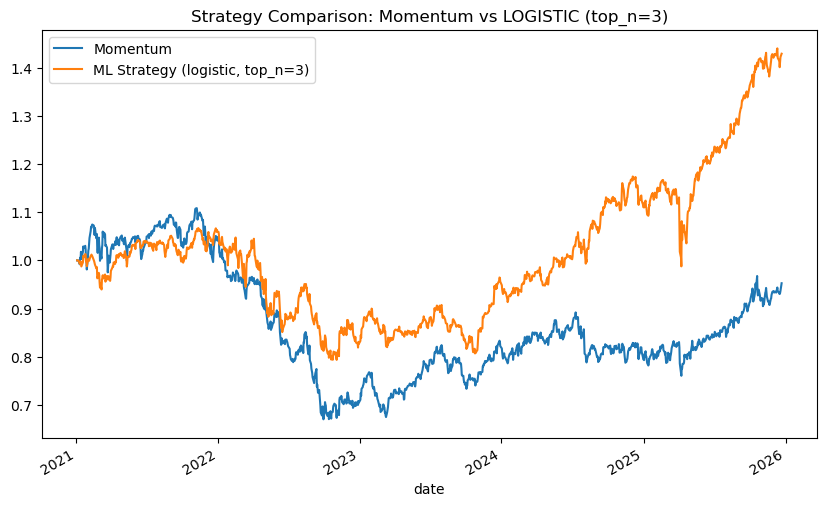

In [17]:
plt.figure(figsize=(10, 6))

baseline_aligned["cum_return"].plot(label="Momentum")
ml_aligned["cum_return"].plot(label=f"ML Strategy ({MODEL_NAME}, top_n={TOP_N})")

plt.legend()
plt.title(f"Strategy Comparison: Momentum vs {MODEL_NAME.upper()} (top_n={TOP_N})")
plt.show()

In [18]:
MODEL_NAME = "rf"
TOP_N = 2
TRAIN_END_DATE = "2020-12-31"

In [19]:
def compute_metrics(portfolio):
    r = portfolio["net_return"].dropna()
    sharpe = (r.mean() / r.std()) * (252 ** 0.5)
    max_dd = (portfolio["cum_return"] / portfolio["cum_return"].cummax() - 1).min()
    return sharpe, max_dd

b_sharpe, b_dd = compute_metrics(baseline_aligned)
m_sharpe, m_dd = compute_metrics(ml_aligned)

print(f"MODEL_NAME = {MODEL_NAME}")
print(f"TOP_N = {TOP_N}")
print("Baseline Sharpe:", b_sharpe)
print("ML Sharpe:", m_sharpe)
print("Baseline DD:", b_dd)
print("ML DD:", m_dd)

MODEL_NAME = rf
TOP_N = 2
Baseline Sharpe: 0.012260530337100105
ML Sharpe: 0.55552265939998
Baseline DD: -0.39515909104736646
ML DD: -0.2561053311781606


In [20]:
import pandas as pd
import matplotlib.pyplot as plt

from quant_ml.config import INTERIM_DATA_DIR
from quant_ml.experiments import run_experiment_grid

In [21]:
df = pd.read_parquet(INTERIM_DATA_DIR / "model_dataset_v1.parquet")
df["date"] = pd.to_datetime(df["date"])

In [22]:
feature_cols = [
    "ret_1d", "ret_5d", "ret_20d", "ret_60d",
    "ma_ratio_20", "ma_ratio_50", "ma_ratio_100", "ma_cross_20_50",
    "vol_20d", "vol_60d",
    "volume_z_20", "volume_ratio_20",
    "fed_funds", "cpi", "unemployment", "10y_treasury", "2y_treasury", "term_spread",
]

target_col = "target_up_5d"

In [23]:
experiment_grid = [
    {"model_name": "logistic", "top_n": 2},
    {"model_name": "logistic", "top_n": 3},
    {"model_name": "logistic", "top_n": 4},
    {"model_name": "rf", "top_n": 2},
    {"model_name": "rf", "top_n": 3},
]

In [24]:
results_df, portfolios = run_experiment_grid(
    df=df,
    feature_cols=feature_cols,
    target_col=target_col,
    train_end_date="2020-12-31",
    experiment_grid=experiment_grid,
    cost_per_trade=0.001,
)

results_df

,experiment_name,model_name,top_n,train_end_date,baseline_sharpe,ml_sharpe,baseline_max_drawdown,ml_max_drawdown,sharpe_improvement,drawdown_improvement,n_test_rows,n_pred_rows,avg_proba_up,std_proba_up
0,rf_top3,rf,3,2020-12-31,0.012261,0.610173,-0.395159,-0.269112,0.597913,0.126047,7494,7494,0.579305,0.038541
1,logistic_top4,logistic,4,2020-12-31,0.012261,0.555523,-0.395159,-0.256105,0.543262,0.139054,7494,7494,0.691478,0.043493
2,logistic_top2,logistic,2,2020-12-31,0.012261,0.548684,-0.395159,-0.203513,0.536423,0.191646,7494,7494,0.691478,0.043493
3,logistic_top3,logistic,3,2020-12-31,0.012261,0.499956,-0.395159,-0.256015,0.487695,0.139144,7494,7494,0.691478,0.043493
4,rf_top2,rf,2,2020-12-31,0.012261,0.429972,-0.395159,-0.322101,0.417712,0.073058,7494,7494,0.579305,0.038541


In [25]:
best_exp_name = results_df.iloc[0]["experiment_name"]
best_exp_name

'rf_top3'

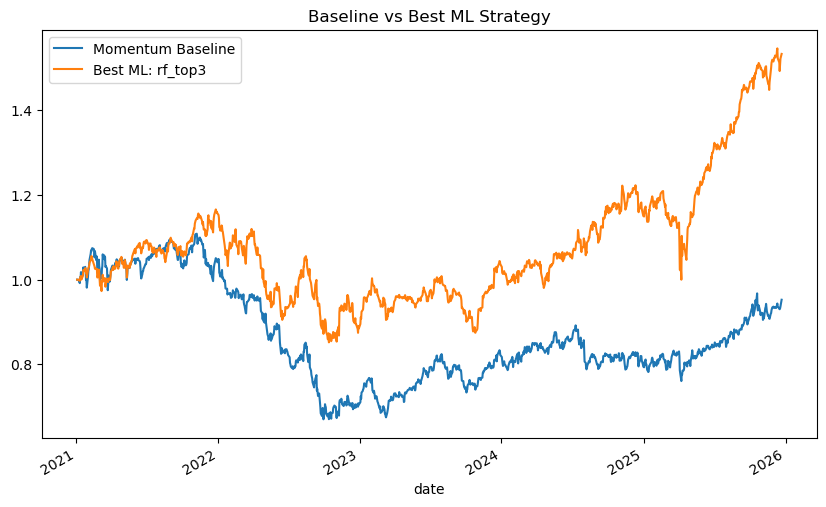

In [26]:
baseline_portfolio = portfolios["baseline"]
best_portfolio = portfolios[best_exp_name]

common_index = baseline_portfolio.index.intersection(best_portfolio.index)

baseline_aligned = baseline_portfolio.loc[common_index]
best_aligned = best_portfolio.loc[common_index]

plt.figure(figsize=(10, 6))
baseline_aligned["cum_return"].plot(label="Momentum Baseline")
best_aligned["cum_return"].plot(label=f"Best ML: {best_exp_name}")
plt.legend()
plt.title("Baseline vs Best ML Strategy")
plt.show()

In [29]:
results_df.to_csv(ARTIFACTS_DIR / "experiment_results.csv", index=False)
results_df.to_parquet(ARTIFACTS_DIR / "experiment_results.parquet", index=False)

In [30]:
list(ARTIFACTS_DIR.iterdir())

[PosixPath('/Users/amirhosseinlatifinavid/Desktop/Programming/Python /quant-ml-backtester/artifacts/experiment_results.csv'),
 PosixPath('/Users/amirhosseinlatifinavid/Desktop/Programming/Python /quant-ml-backtester/artifacts/experiment_results.parquet')]

In [31]:
best_exp_name = "rf_top3"
best_portfolio = portfolios[best_exp_name].copy()

best_portfolio.to_parquet(ARTIFACTS_DIR / "best_portfolio_rf_top3.parquet")

In [32]:
logistic_portfolio = portfolios["logistic_top2"].copy()
logistic_portfolio.to_parquet(ARTIFACTS_DIR / "benchmark_portfolio_logistic_top2.parquet")

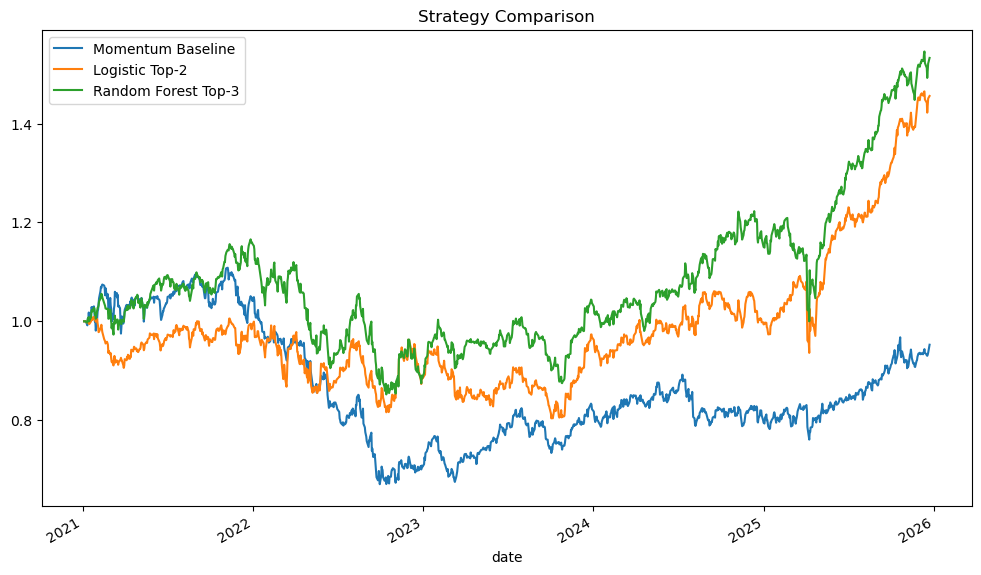

In [33]:
baseline_portfolio = portfolios["baseline"]
rf_top3_portfolio = portfolios["rf_top3"]
logistic_top2_portfolio = portfolios["logistic_top2"]

common_index = baseline_portfolio.index
common_index = common_index.intersection(rf_top3_portfolio.index)
common_index = common_index.intersection(logistic_top2_portfolio.index)

baseline_aligned = baseline_portfolio.loc[common_index]
rf_top3_aligned = rf_top3_portfolio.loc[common_index]
logistic_top2_aligned = logistic_top2_portfolio.loc[common_index]

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))
baseline_aligned["cum_return"].plot(label="Momentum Baseline")
logistic_top2_aligned["cum_return"].plot(label="Logistic Top-2")
rf_top3_aligned["cum_return"].plot(label="Random Forest Top-3")
plt.legend()
plt.title("Strategy Comparison")
plt.show()

In [34]:
final_compare = results_df.loc[
    results_df["experiment_name"].isin(["logistic_top2", "rf_top3"]),
    [
        "experiment_name",
        "ml_sharpe",
        "ml_max_drawdown",
        "sharpe_improvement",
        "drawdown_improvement",
    ],
].copy()

final_compare

,experiment_name,ml_sharpe,ml_max_drawdown,sharpe_improvement,drawdown_improvement
0,rf_top3,0.610173,-0.269112,0.597913,0.126047
2,logistic_top2,0.548684,-0.203513,0.536423,0.191646
